<a href="https://colab.research.google.com/github/semanrbingl/ai-ecommerce-product-generator/blob/main/notebooks/02_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
import kagglehub
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
DATA_DIR = path
print(path)

Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
/kaggle/input/fashion-product-images-small


In [3]:
# veriyi tekrar hazırlıyorum
import os
import pandas as pd

df = pd.read_csv(os.path.join(DATA_DIR, "styles.csv"), on_bad_lines = "skip")
df["image_path"] = df["id"].astype(str).apply(
    lambda x: os.path.join(DATA_DIR, "images", x + ".jpg")
)
df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

print("Toplam ürün:", len(df))

Toplam ürün: 44419


In [4]:
TOP_N = 20
MIN_SAMPLES = 500
counts = df["articleType"].value_counts()
raw_counts = counts.head(TOP_N)
top_classes = raw_counts[raw_counts >= MIN_SAMPLES].index.to_list()

df_model = df[df["articleType"].isin(top_classes)].reset_index(drop=True).copy()

print("Sınıf sayısı:", len(top_classes))
print("Toplam görsel:", len(df_model))

Sınıf sayısı: 20
Toplam görsel: 33142


In [5]:
#etiketleri sayıya çeviriyorum
class_names = sorted(df_model['articleType'].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}

df_model["label"] = df_model['articleType'].map(class_to_idx)

print("Sınıf sayısı:", len(class_names))
print(class_to_idx)

Sınıf sayısı: 20
{'Backpacks': 0, 'Belts': 1, 'Briefs': 2, 'Casual Shoes': 3, 'Flip Flops': 4, 'Formal Shoes': 5, 'Handbags': 6, 'Heels': 7, 'Jeans': 8, 'Kurtas': 9, 'Perfume and Body Mist': 10, 'Sandals': 11, 'Shirts': 12, 'Socks': 13, 'Sports Shoes': 14, 'Sunglasses': 15, 'Tops': 16, 'Tshirts': 17, 'Wallets': 18, 'Watches': 19}


In [6]:
#Train, validationi test

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_model, test_size=0.30, stratify=df_model["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 23199
Validation: 4971
Test: 4972


In [7]:
from torch.utils.data import Dataset
from PIL import Image

class ProductImageDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, index):
    row = self.dataframe.iloc[index]
    image = Image.open(row["image_path"]).convert("RGB")
    label = row["label"]

    if self.transform:
      image = self.transform(image)

    return image,label

In [8]:
from torchvision import transforms

IMG_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataset = ProductImageDataset(train_df, transform=train_transform)
val_dataset = ProductImageDataset(val_df, transform=eval_transform)
test_dataset = ProductImageDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print("Batch görsel boyutu:", images.shape)
print("Batch etiket boyutu:", labels.shape)


Batch görsel boyutu: torch.Size([32, 3, 224, 224])
Batch etiket boyutu: torch.Size([32])


In [10]:
from torchvision import models
import torch.nn as nn

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
# ResNet50_Weights.IMAGENET1K_V2:
# IMAGENET1K = ImageNet'in 1000 kategorisiyle eğitilmiş ağırlıklar
# V2 = bu ağırlıkların 2. (daha güncel, daha başarılı) sürümü

for param in model.parameters():
  param.requires_grad = False

num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device )

model = model.to(device)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Kullanılan cihaz: cuda
Linear(in_features=2048, out_features=20, bias=True)


In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() #loss function tanımladım
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3) #1e-3=0.001

In [12]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    torch.set_grad_enabled(is_train)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        _, preds = torch.max(outputs, 1)  #_ ile atıp yok sayıyoruz, ihtiyacımız yok
        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

In [13]:
import copy
import time

NUM_EPOCHS = 5

best_val_acc = 0.0
best_model_weights = copy.deepcopy(model.state_dict())
history = []

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
    })

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = copy.deepcopy(model.state_dict())

elapsed = time.time() - start_time
print(f"\nToplam süre: {elapsed/60:.1f} dakika")
print(f"En iyi validation doğruluğu: {best_val_acc:.4f}")

model.load_state_dict(best_model_weights)

Epoch 1/5 | Train loss: 0.8569 acc: 0.7533 | Val loss: 0.5360 acc: 0.8407
Epoch 2/5 | Train loss: 0.4765 acc: 0.8444 | Val loss: 0.4410 acc: 0.8664
Epoch 3/5 | Train loss: 0.4053 acc: 0.8631 | Val loss: 0.4036 acc: 0.8672
Epoch 4/5 | Train loss: 0.3650 acc: 0.8778 | Val loss: 0.3745 acc: 0.8743
Epoch 5/5 | Train loss: 0.3400 acc: 0.8824 | Val loss: 0.3714 acc: 0.8769

Toplam süre: 9.2 dakika
En iyi validation doğruluğu: 0.8769


<All keys matched successfully>

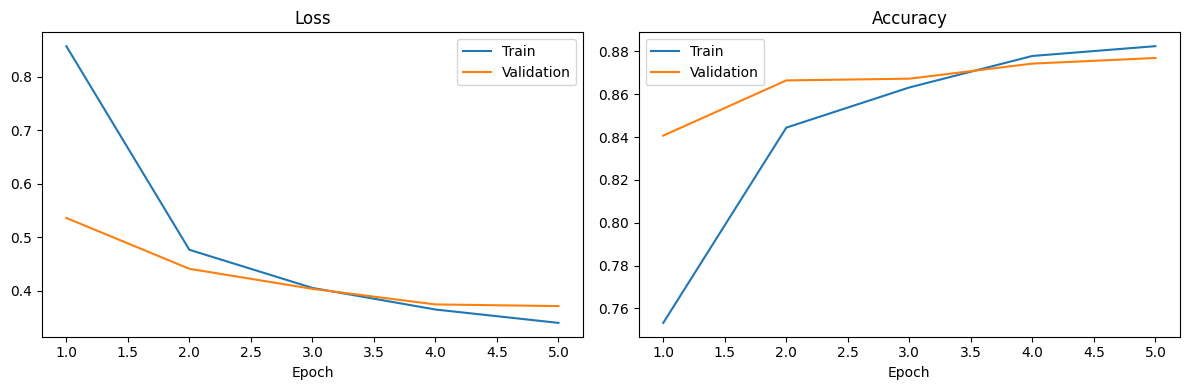

In [15]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["train_acc"], label="Train")
axes[1].plot(hist_df["epoch"], hist_df["val_acc"], label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer=None)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.3915
Test accuracy: 0.8671


In [17]:
# kaydetme adımı

idx_to_class = {i: name for name, i in class_to_idx.items()}
print(idx_to_class)

{0: 'Backpacks', 1: 'Belts', 2: 'Briefs', 3: 'Casual Shoes', 4: 'Flip Flops', 5: 'Formal Shoes', 6: 'Handbags', 7: 'Heels', 8: 'Jeans', 9: 'Kurtas', 10: 'Perfume and Body Mist', 11: 'Sandals', 12: 'Shirts', 13: 'Socks', 14: 'Sports Shoes', 15: 'Sunglasses', 16: 'Tops', 17: 'Tshirts', 18: 'Wallets', 19: 'Watches'}


In [19]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/ai_ecommerce_product_generator"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
}, os.path.join(SAVE_DIR, "baseline_resnet50.pth"))

print("Kaydedildi:", os.path.join(SAVE_DIR, "baseline_resnet50.pth"))

Mounted at /content/drive
Kaydedildi: /content/drive/MyDrive/ai_ecommerce_product_generator/baseline_resnet50.pth


In [20]:
import os
print(os.path.exists("/content/drive/MyDrive"))


True


ÖZET


test accuracy: %86.7
overfitting: 4. epoch'tan sonra hafif başladı ama ciddi değil
